In [3]:
!pip install rdkit
!pip install chembl_structure_pipeline

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.
"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


**0. Importación de módulos y paquetes necesarios**

Importe todos los módulos y paquetes necesarios para el desarrollo de las actividades (por ejemplo: pandas, numpy, rdkit, etc.), incluyendo comentarios breves que expliquen para qué se usará cada paquete principal.

In [17]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

**1. Carga de datos**

Lea como DataFrame de pandas las dos quimiotecas proporcionadas y responda:

*   ¿Cuántos compuestos distintos (SMILES) tienen alguna actividad reportada contra el Factor de Coagulación X?

*   ¿Cuántos compuestos distintos (SMILES) incluye la colección de ENAMINE proporcionada?

In [4]:
# Cargamos los archivos como DataFrame usando pandas
enamine = pd.read_csv('data/YoatzinTorres-Enamine_DD10.csv')
bioactivity = pd.read_csv('data/YoatzinTorres-Bioactivity_data.csv')

print("¿Cuántos compuestos distintos (SMILES) tienen alguna actividad reportada contra el Factor de Coagulación X?")
# Para resolver esta pregunta, primero filtramos con 'loc' para seleccionar todas las columnas que cumplan con
# tener alguna actividad reportada contra el Factor de Coagulación X, y una vez filtrada esa información,
# realizamos el conteo de cuantos Smiles distintos se han reportado.
print(bioactivity.loc[bioactivity["Target Name"] == "Coagulation factor X", "Smiles"].nunique())
# Para esta preguunta, ocupamos la función de pandas 'nunique', que hace un conteo de elementos
# distintos, para este ejercicio la información dada es únicamente la columna SMILES del archivo enamine
print("¿Cuántos compuestos distintos (SMILES) incluye la colección de ENAMINE proporcionada?")
print(enamine["SMILES"].nunique())

¿Cuántos compuestos distintos (SMILES) tienen alguna actividad reportada contra el Factor de Coagulación X?
7669
¿Cuántos compuestos distintos (SMILES) incluye la colección de ENAMINE proporcionada?
10240


**Breve discusión**

**2. Preparación de los datos**

Para el conjunto de datos de compuestos bioactivos:
*   Conserve solamente los datos que tengan un valor de "pChEMBL Value" asociado y cuya actividad haya sido medida como "Ki".
*   Responda, ¿En el conjunto de datos filtrado hay compuestos duplicados?. De ser así, elimine duplicados (por Smiles) conservando solo el valor de afinidad más alto reportado para cada compuesto.
*   Responda, ¿Hay fármacos aprobados en el conjunto de datos final?. De ser así, indique cuántos son y muestre sus estructuras.

Conserve solamente los datos que tengan un valor de "pChEMBL Value" asociado y cuya actividad haya sido medida como "Ki".
Responda, ¿En el conjunto de datos filtrado hay compuestos duplicados?. De ser así, elimine duplicados (por Smiles) conservando solo el valor de afinidad más alto reportado para cada compuesto.
¿Existen duplicados? Sí

Responda, ¿Hay fármacos aprobados en el conjunto de datos final?. De ser así, indique cuántos son y muestre sus estructuras.
Total de farmacos aprobados:  6


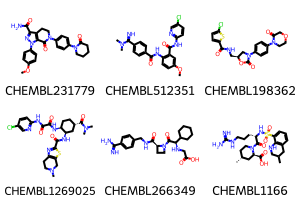

In [24]:
print("""Conserve solamente los datos que tengan un valor de "pChEMBL Value" asociado y cuya actividad haya sido medida como "Ki".""")
# Para resolver este punto, lo que tenemos que hacer es, nuevamente con 'loc', de nuestro df bioactivity filtramos
# los que en la columna 'Standard Type' sea 'Ki' y que tenga un valor en 'pChEMBL Value'
filtered_bioactivity = bioactivity.loc[
    (bioactivity["Standard Type"] == "Ki") &
    (bioactivity["pChEMBL Value"].notnull())
]

print("Responda, ¿En el conjunto de datos filtrado hay compuestos duplicados?. De ser así, elimine duplicados (por Smiles) conservando solo el valor de afinidad más alto reportado para cada compuesto.")
# Para responder esta pregunta son dos partes, para saber si hay duplicados podemos hacer una comparación entre el número total
# y el número de distintos con una columna que no esté nula en ningún caso. Ej. Smiles
duplicados = filtered_bioactivity["Smiles"].count != filtered_bioactivity["Smiles"].nunique()
print(f"¿Existen duplicados? {'Sí' if duplicados else 'No'}")
# Continuando con la siguiente parte, tenemos que hacer un nuevo filtrado para eliminar los 'Smiles' repetidos conservando
# el que tiene el valor de afinidad más alto reportado, para hacer esto, ordenamos de mayor a menor por la columna 'pChEMBL Value'
# y de la columna Smiles mantenemos siempre el primer resultado y eliminamos los demás
filtered_bioactivity_max = (
    filtered_bioactivity
    .sort_values("pChEMBL Value", ascending=False)
    .drop_duplicates(subset="Smiles", keep="first")
    .reset_index(drop=True)
)

print("\nResponda, ¿Hay fármacos aprobados en el conjunto de datos final?. De ser así, indique cuántos son y muestre sus estructuras.")
# Esta pregunta nuevamente se responde en dos partes, primero extraemos del df final todos aquellos que cuentan con un
# “Molecule Max Phase” de la base de datos “bioactivity” igual a 4
farmacos_aprobados = filtered_bioactivity_max.loc[
    filtered_bioactivity_max["Molecule Max Phase"] == 4
]
# Con el df final, filtramos aquellos que en Molecule Max Phase su valor sea igual a 4 e imprimimos el conteo de los
# que cumplan esa condición.
print(f"Total de farmacos aprobados: ", farmacos_aprobados["Smiles"].count())
# Para la segunda parte, tenemos que obtener el Molecule ChEMBL ID de esos 'n' farmacos aprobados junto con sus estructuras
# ocupando la librería chem de rdkit
farmacos_aprobados = farmacos_aprobados.assign(
    Mol=farmacos_aprobados["Smiles"].apply(Chem.MolFromSmiles)
)

ids = farmacos_aprobados["Molecule ChEMBL ID"].head(farmacos_aprobados["Smiles"].count()).tolist()
mols = farmacos_aprobados["Mol"].head(farmacos_aprobados["Smiles"].count()).tolist()

img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(100,100), legends=ids)
display(img)

**Breve discusión**

Para ambos conjuntos de datos:
*   Aplique el proceso de estandarización de ChEMBL a todos los SMILES, añadiendo en una nueva columna (Canonical SMILES) el resultado de este proceso.
*   A partir del Canonical SMILES generado, añada una nueva columna con el InChiKey para cada uno de los compuestos.
*   Responda, ¿Se identificaron duplicados dentro de cada conjunto de datos después de la estandarización?
*   En caso de identificar nuevos duplicados, eliminelos conservando la primera ocurrencia de cada uno de ellos en los respectivos conjuntos de datos.
*   Responda, ¿Hay compuestos que ocurren en ambas bases de datos? De ser así, identifiquelos y muestre sus estructuras. Posteriormente eliminelos del conjunto de datos de Enamine.

**Breve discusión**

**3. Análisis de Scaffolds**

*   Cálcule el Scaffold de Bemis y Murcko (en formato SMILES) para cada compuesto en ambos conjuntos de datos.
*   Responda, ¿Cuántos Scaffolds únicos hay en cada conjunto de datos Considerando la relación entre el número de Scaffolds únicos respecto al número de moléculas en cada conjunto, ¿qué conjunto de datos es más diverso?, ¿Hay Scaffolds que aparezcan en ambos conjutnos de datos? De ser así, identfíquelos, muestre sus estructuras y posteriormente eliminelos del conjunto de datos de Enamine.

**Breve discusión**


**4. Cálculo de descriptores de interés farmacéutico.**

*   Cálcule los descriptores de Lipinski y Veber para todos los compuestos en ambos conjuntos de datos
*   Construya diagramas de caja y bigote (boxplots) comparando las distribuciones de estos descriptores para ambas bases de datos
*   Responda, ¿Cuántos compuestos de cada conjunto de datos no cumplen las reglas de Lipinski y Veber?, ¿Alguno de estos descriptores muestra una marcada diferencia entre los conjuntos de datos?

**Breve discusión**

**5. Cálculo de huellas digitales moleculares y visualización del espacio químico**

*   Calcule las huellas digitales tipo Morgan (radio 2, 1024 bits) para todos los compuestos de ambos conjuntos.
*   Utilizando los descriptres de interés farmacéutico calculados en la sección anterior, contruya un a visualización del espacio químico en 2D mediante análisis de componentes principales (sin elminiación de datos atípicos) coloreando los puntos de acuerdo al conjunto de datos al que pertenecen.
*   Utilizando las huellas digitales calculadas, consruya una visualización del espacio químico en 2D usando la técnica t-SNE coloreando los puntos de acuerdo al conjunto de datos al que pertenecen.
*   A partir de las visualizaciones generadas responda, ¿El conjunto de compuestos bioactivos ocupa una región compacta o muy dispersa?, ¿Los compuestos de ENAMINE cubren la región ocupada por los compuestos bioactivos o están desplazados de estos?

**Breve discusión**

**6. Cribado virtual (Mini)**

*   Seleccione un compuesto de referencia dentro de la base de datos de compuestos bioactivos (el más potente, alguno de los fármacos aprobados, etc.) y muestre su estructura.
*   Cálcule la similitud de todos los compuestos en la base de datos Enamine con respecto al compuesto seleccionado y añada ese valor como una columna adicional (Similarity).
*   Construya un histograma con las similitudes obtenidas, señalando el valor que permitiría seleccionar el 1% de las moléculas más parecidas a la molécula de referencia seleccionada.
*   Responda, ¿Cuántas moléculas de Enamine estarían por encima del umbral seleccionado? Considerando la representación y métrica empleada para el cálculo de similitud, ¿Considera que este es un umbral alto o bajo?
*   Seleccione las 10 moléculas más parecidas a las moléculas de referencia y muestre su estructura junto con su identificador.
*   Grafique nuevamente las dos visualizaciones del espacio químico señaladas en la sección anterior, señalando la ubicación de los 10 compuestos seleccionados.
*   Considerando todos los análisis elaborados, explique si considera que esos 10 compuestos serían buenos candidatos para llevarlos a validación experimental frente al blanco biológico estudiado.



**Discusión Final**